In [29]:
import pandas as pd

df = pd.read_csv('data/clients.csv')
display(df)

,id_cliente,mes,idade,profissao,salario_anual,num_contas,num_cartoes,juros_emprestimo,num_emprestimos,dias_atraso,...,idade_historico_credito,investimento_mensal,comportamento_pagamento,saldo_final_mes,score_credito,emprestimo_carro,emprestimo_casa,emprestimo_pessoal,emprestimo_credito,emprestimo_estudantil
0,3392,1,23.0,cientista,19114.12,3.0,4.0,3.0,4.0,3.0,...,265.0,21.465380,alto_gasto_pagamento_baixos,312.494089,Good,1,1,1,1,0
1,3392,2,23.0,cientista,19114.12,3.0,4.0,3.0,4.0,3.0,...,266.0,21.465380,baixo_gasto_pagamento_alto,284.629162,Good,1,1,1,1,0
2,3392,3,23.0,cientista,19114.12,3.0,4.0,3.0,4.0,3.0,...,267.0,21.465380,baixo_gasto_pagamento_medio,331.209863,Good,1,1,1,1,0
3,3392,4,23.0,cientista,19114.12,3.0,4.0,3.0,4.0,5.0,...,268.0,21.465380,baixo_gasto_pagamento_baixo,223.451310,Good,1,1,1,1,0
4,3392,5,23.0,cientista,19114.12,3.0,4.0,3.0,4.0,6.0,...,269.0,21.465380,alto_gasto_pagamento_medio,341.489231,Good,1,1,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,37932,4,25.0,mecanico,39628.99,4.0,6.0,7.0,2.0,23.0,...,378.0,24.028477,alto_gasto_pagamento_alto,479.866228,Poor,1,0,0,0,1
99996,37932,5,25.0,mecanico,39628.99,4.0,6.0,7.0,2.0,18.0,...,379.0,24.028477,alto_gasto_pagamento_medio,496.651610,Poor,1,0,0,0,1
99997,37932,6,25.0,mecanico,39628.99,4.0,6.0,7.0,2.0,27.0,...,380.0,24.028477,alto_gasto_pagamento_alto,516.809083,Poor,1,0,0,0,1
99998,37932,7,25.0,mecanico,39628.99,4.0,6.0,7.0,2.0,20.0,...,381.0,24.028477,baixo_gasto_pagamento_alto,319.164979,Standard,1,0,0,0,1


In [30]:
display(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 25 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   id_cliente                100000 non-null  int64  
 1   mes                       100000 non-null  int64  
 2   idade                     100000 non-null  float64
 3   profissao                 100000 non-null  str    
 4   salario_anual             100000 non-null  float64
 5   num_contas                100000 non-null  float64
 6   num_cartoes               100000 non-null  float64
 7   juros_emprestimo          100000 non-null  float64
 8   num_emprestimos           100000 non-null  float64
 9   dias_atraso               100000 non-null  float64
 10  num_pagamentos_atrasados  100000 non-null  float64
 11  num_verificacoes_credito  100000 non-null  float64
 12  mix_credito               100000 non-null  str    
 13  divida_total              100000 non-null  float64
 14  

None

In [31]:
from sklearn.preprocessing import LabelEncoder

"""
cientista - 1
bombeiro - 2
engenheiro - 3
dentista - 4
artista - 5
"""

codificador_profissao = LabelEncoder()
df["profissao"] = codificador_profissao.fit_transform(df["profissao"])

# mix crédito
codificador_credito = LabelEncoder()
df["mix_credito"] = codificador_credito.fit_transform(df["mix_credito"])

# comportamento_pagamento
codificador_pagamento = LabelEncoder()
df["comportamento_pagamento"] = codificador_pagamento.fit_transform(df["comportamento_pagamento"])

display(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 25 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   id_cliente                100000 non-null  int64  
 1   mes                       100000 non-null  int64  
 2   idade                     100000 non-null  float64
 3   profissao                 100000 non-null  int64  
 4   salario_anual             100000 non-null  float64
 5   num_contas                100000 non-null  float64
 6   num_cartoes               100000 non-null  float64
 7   juros_emprestimo          100000 non-null  float64
 8   num_emprestimos           100000 non-null  float64
 9   dias_atraso               100000 non-null  float64
 10  num_pagamentos_atrasados  100000 non-null  float64
 11  num_verificacoes_credito  100000 non-null  float64
 12  mix_credito               100000 non-null  int64  
 13  divida_total              100000 non-null  float64
 14  

None

In [32]:
# y 
y = df["score_credito"]

# x 
x = df.drop(columns=["score_credito", "id_cliente"])

# separar em dados de treino e dados de teste
from sklearn.model_selection import train_test_split

x_treino, x_teste, y_treino, y_teste = train_test_split(x, y, test_size=0.3)

In [33]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# criar a IA
modelo_arvoredecisao = RandomForestClassifier()
modelo_knn = KNeighborsClassifier()

# treinar a IA
modelo_arvoredecisao.fit(x_treino, y_treino)
modelo_knn.fit(x_treino, y_treino)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [34]:
previsao_arvoredecisao = modelo_arvoredecisao.predict(x_teste)
previsao_knn = modelo_knn.predict(x_teste)

# acurácia
from sklearn.metrics import accuracy_score
display(accuracy_score(y_teste, previsao_arvoredecisao))
display(accuracy_score(y_teste, previsao_knn))

0.8228

0.7332

In [35]:
df_novos_clientes = pd.read_csv("data/new_clients.csv")

# profissao
df_novos_clientes["profissao"] = codificador_profissao.transform(
    df_novos_clientes["profissao"])


# mix_credito
df_novos_clientes["mix_credito"] = codificador_credito.transform(
    df_novos_clientes["mix_credito"])

# comportamento_pagamento
df_novos_clientes["comportamento_pagamento"] = codificador_pagamento.transform(
    df_novos_clientes["comportamento_pagamento"])


display(df_novos_clientes)

nova_previsao = modelo_arvoredecisao.predict(df_novos_clientes)
display(nova_previsao)


,mes,idade,profissao,salario_anual,num_contas,num_cartoes,juros_emprestimo,num_emprestimos,dias_atraso,num_pagamentos_atrasados,...,taxa_uso_credito,idade_historico_credito,investimento_mensal,comportamento_pagamento,saldo_final_mes,emprestimo_carro,emprestimo_casa,emprestimo_pessoal,emprestimo_credito,emprestimo_estudantil
0,1,31.0,5,19300.340,6.0,7.0,17.0,5.0,52.0,19.0,...,29.934186,218.0,44.50951,4,312.487689,1,1,0,0,0
1,4,32.0,0,12600.445,5.0,5.0,10.0,3.0,25.0,18.0,...,28.819407,12.0,0.00000,5,300.994163,0,0,0,0,1
2,2,48.0,5,20787.690,8.0,6.0,14.0,7.0,24.0,14.0,...,34.235853,215.0,0.00000,3,345.081577,0,1,0,1,0


array(['Poor', 'Poor', 'Standard'], dtype=object)

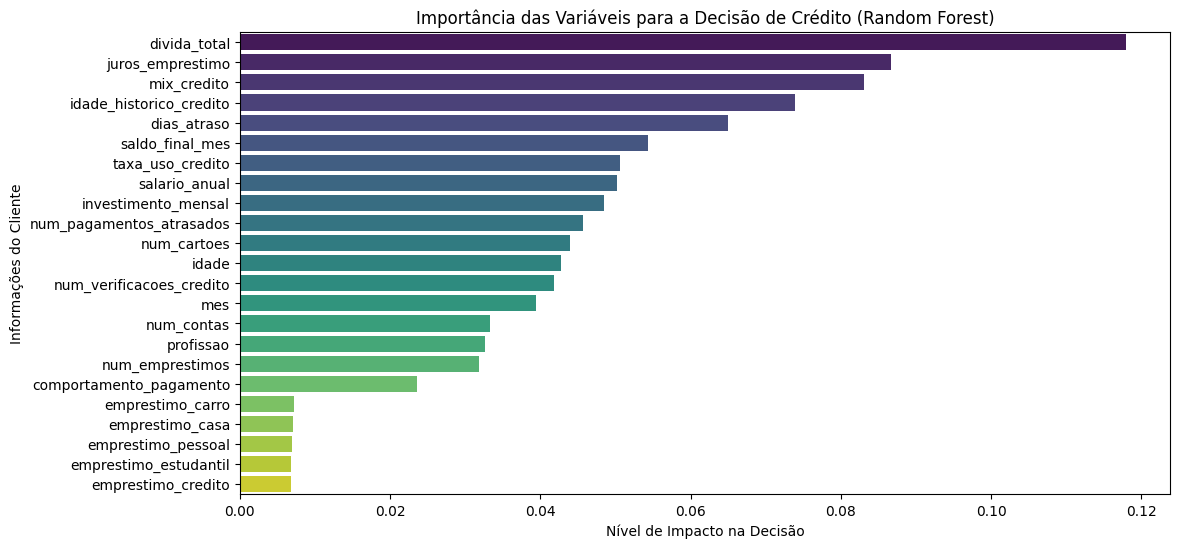

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Pegando os nomes das colunas usadas no treinamento e o peso de cada uma
colunas = x.columns
importancia = modelo_arvoredecisao.feature_importances_

# Criando uma tabela para organizar da mais importante para a menos importante
df_importancia = pd.DataFrame({"Variável": colunas, "Importância": importancia})
df_importancia = df_importancia.sort_values(by="Importância", ascending=False)

# Criando o gráfico
plt.figure(figsize=(12, 6))
sns.barplot(x="Importância", y="Variável", data=df_importancia, hue="Variável", palette="viridis", legend=False)
plt.title("Importância das Variáveis para a Decisão de Crédito (Random Forest)")
plt.xlabel("Nível de Impacto na Decisão")
plt.ylabel("Informações do Cliente")
plt.show()

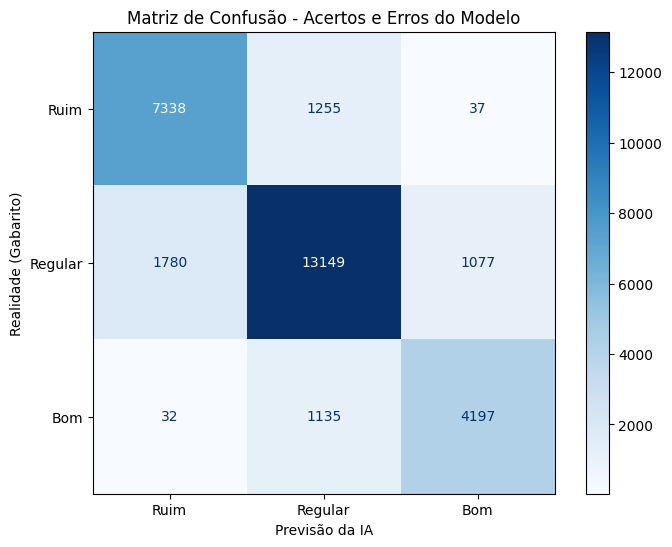

In [41]:
# Fazendo a previsão usando os dados de teste (os 30% separados no começo)
previsao_teste = modelo_arvoredecisao.predict(x_teste)

# Criando e plotando a matriz de confusão
matriz = confusion_matrix(y_teste, previsao_teste, labels=["Poor", "Standard", "Good"])
disp = ConfusionMatrixDisplay(confusion_matrix=matriz, display_labels=["Ruim", "Regular", "Bom"])

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap="Blues", values_format="d", ax=ax)
plt.title("Matriz de Confusão - Acertos e Erros do Modelo")
plt.xlabel("Previsão da IA")
plt.ylabel("Realidade (Gabarito)")
plt.show()